Importing Libraries and Dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_rental = pd.read_excel("bike_rentals_dirty_datasets.xlsx",
                          sheet_name = "Dirty_Dataset_09")

1. Exploratory Data Analysis (EDA)

In [ ]:
#1.1 General Discription of The Database

In [ ]:
df_rental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10872 entries, 0 to 10871
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   time        10828 non-null  object        
 1   date        10851 non-null  datetime64[ns]
 2   season      10821 non-null  object        
 3   holiday     10835 non-null  object        
 4   workingday  10818 non-null  object        
 5   weather     10824 non-null  object        
 6   temp        10825 non-null  object        
 7   atemp       10827 non-null  object        
 8   humidity    10833 non-null  object        
 9   windspeed   10825 non-null  object        
 10  casual      10757 non-null  float64       
 11  registered  10751 non-null  float64       
 12  count       10768 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(9)
memory usage: 1.1+ MB


In [ ]:
#1.1 Possible Values for Each Variable
print(df_rental['time'].unique())
print(df_rental['date'].unique())
print(df_rental['season'].unique())
print(df_rental['holiday'].unique())
print(df_rental['workingday'].unique())
print(df_rental['weather'].unique())
print(df_rental['temp'].unique())
print(df_rental['atemp'].unique())
print(df_rental['humidity'].unique())
print(df_rental['windspeed'].unique())
print(df_rental['casual'].unique())
print(df_rental['registered'].unique())
print(df_rental['count'].unique())

['00:00:00' '01:00:00' '02:00:00' '03:00:00' '04:00:00' '05:00:00'
 '06:00:00' '07:00:00' '08:00:00' '09:00:00' '10:00:00' '11:00:00'
 '12:00:00' '13:00:00' '14:00:00' '15:00:00' '16:00:00' '17:00:00'
 '18:00:00' '25:00' '20:00:00' '21:00:00' '22:00:00' '23:00:00' '12:99'
 '19:00:00' '-05:00' nan 'Not Available' '99:99' 1.166666666666667
 datetime.datetime(2000, 1, 28, 0, 0)]
<DatetimeArray>
['2024-01-01 00:00:00', '2024-01-02 00:00:00', '2024-01-03 00:00:00',
 '2024-01-04 00:00:00', '2024-01-05 00:00:00', '2024-01-06 00:00:00',
 '2024-01-07 00:00:00', '2024-01-08 00:00:00', '2024-01-09 00:00:00',
 '2024-01-10 00:00:00',
 ...
 '2025-12-10 00:00:00', '2025-12-11 00:00:00', '2025-12-12 00:00:00',
 '2025-12-13 00:00:00', '2025-12-14 00:00:00', '2025-12-15 00:00:00',
 '2025-12-16 00:00:00', '2025-12-17 00:00:00', '2025-12-18 00:00:00',
 '2025-12-19 00:00:00']
Length: 457, dtype: datetime64[ns]
[1 nan 5 'Summer' 0 -1 99 2 3 4]
[0 -1 0.5 nan 3 2 1 'Yes' 99]
[0 0.5 -1 1 nan 'Yes' 99 2 'No']
[

In [ ]:
# 1.1 Null Values
print(df_rental.isnull().sum())


time           44
date           21
season         51
holiday        37
workingday     54
weather        48
temp           47
atemp          45
humidity       39
windspeed      47
casual        115
registered    121
count         104
dtype: int64


1.2 Identifying Unusual/Incorrect Values

In [ ]:
# 1.2 Identifying Unusual/Incorrect Values (Refined with Column Definitions)

def get_non_numeric(series):
    return series[pd.to_numeric(series, errors='coerce').isna() & series.notna()].unique()

print("--- Data Anomalies Report (Based on Schema) ---")

# 1. Time & Date (Formatting check)
invalid_times = df_rental[~df_rental['time'].astype(str).str.match(r'^([01]?[0-9]|2[0-3]):[0-5][0-9](:[0-5][0-9])?$', na=False)]['time'].unique()
print(f"Invalid Time Formats: {invalid_times}")

# 2. Categorical Validation
# Season: 1, 2, 3, 4
invalid_seasons = [v for v in df_rental['season'].unique() if v not in [1, 2, 3, 4] and pd.notna(v)]
print(f"Invalid Seasons (Expected 1-4): {invalid_seasons}")

# Holiday: 0, 1
invalid_holidays = [v for v in df_rental['holiday'].unique() if v not in [0, 1] and pd.notna(v)]
print(f"Invalid Holiday values (Expected 0/1): {invalid_holidays}")

# Workingday: 0, 1
invalid_workingdays = [v for v in df_rental['workingday'].unique() if v not in [0, 1] and pd.notna(v)]
print(f"Invalid Workingday values (Expected 0/1): {invalid_workingdays}")

# Weather: 1, 2, 3, 4
invalid_weather = [v for v in df_rental['weather'].unique() if v not in [1, 2, 3, 4] and pd.notna(v)]
print(f"Invalid Weather (Expected 1-4): {invalid_weather}")

# 3. Numeric Ranges (Temp, Atemp, Humidity, Windspeed)
numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed']
for col in numeric_cols:
    non_num = get_non_numeric(df_rental[col])
    if len(non_num) > 0:
        print(f"Non-numeric values in {col}: {non_num}")

    vals = pd.to_numeric(df_rental[col], errors='coerce')
    # Logic checks: Humidity should be 0-100, Windspeed >= 0
    if col == 'humidity':
        outliers = vals[(vals < 0) | (vals > 100)].unique()
    elif col == 'windspeed':
        outliers = vals[vals < 0].unique()
    else:
        outliers = vals[(vals < -30) | (vals > 60)].unique() # Reasonable temp range

    if len(outliers) > 0:
        print(f"Out-of-range values in {col}: {outliers}")

# 4. Rental Counts (Non-negative)
for col in ['casual', 'registered', 'count']:
    neg_counts = df_rental[df_rental[col] < 0][col].unique()
    if len(neg_counts) > 0:
        print(f"Negative counts in {col}: {neg_counts}")

# 5. Logic Check: casual + registered == count
# We'll check for rows where the sum doesn't match the total
mismatch = df_rental[pd.notna(df_rental['casual']) & pd.notna(df_rental['registered']) & pd.notna(df_rental['count'])]
mismatch = mismatch[mismatch['casual'] + mismatch['registered'] != mismatch['count']]
if not mismatch.empty:
    print(f"Found {len(mismatch)} rows where casual + registered does not equal total count.")

--- Data Anomalies Report (Based on Schema) ---
Invalid Time Formats: ['25:00' '12:99' '-05:00' nan 'Not Available' '99:99' 1.166666666666667
 datetime.datetime(2000, 1, 28, 0, 0)]
Invalid Seasons (Expected 1-4): [5, 'Summer', 0, -1, 99]
Invalid Holiday values (Expected 0/1): [-1, 0.5, 3, 2, 'Yes', 99]
Invalid Workingday values (Expected 0/1): [0.5, -1, 'Yes', 99, 2, 'No']
Invalid Weather (Expected 1-4): ['Sunny', 99, 0, 5, -2]
Non-numeric values in temp: ['cold']
Out-of-range values in temp: [ -50. -999.  100.]
Non-numeric values in atemp: ['cold']
Out-of-range values in atemp: [-999.  100.  -50. -100.]
Non-numeric values in humidity: ['high']
Out-of-range values in humidity: [-10. 150. 999. -30.]
Non-numeric values in windspeed: ['calm']
Out-of-range values in windspeed: [-100.   -5.]
Negative counts in casual: [-999.  -10.]
Negative counts in registered: [-999.  -10.]
Negative counts in count: [ -10. -999.]
Found 374 rows where casual + registered does not equal total count.


1.3 Numerical Statistics of Each Variable

In [ ]:
# 1.3 Numerical Statistics for Central Tendency and Spread

# Define numerical columns based on schema
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Convert to numeric, coercing errors to NaN so statistics can be calculated
df_numeric = df_rental[num_cols].apply(pd.to_numeric, errors='coerce')

# Calculate basic statistics (Mean, Std, Min, 25%, 50%/Median, 75%, Max)
stats = df_numeric.describe().T

# Add Median explicitly (already in 50%), Mode, and Variance
stats['median'] = df_numeric.median()
stats['mode'] = df_numeric.mode().iloc[0]
stats['variance'] = df_numeric.var()
stats['IQR'] = stats['75%'] - stats['25%']
stats['range'] = stats['max'] - stats['min']

print("--- Central Tendency and Spread Measures ---")
print(stats[['mean', 'median', 'mode', 'std', 'variance', 'range', 'IQR']])

--- Central Tendency and Spread Measures ---
                   mean    median   mode          std      variance    range  \
temp          15.640964    20.500  14.76    68.554840  4.699766e+03   1099.0   
atemp         19.731526    24.240  31.06    63.102055  3.981869e+03   1099.0   
humidity      65.329259    62.000  88.00    62.562966  3.914125e+03   1029.0   
windspeed     17.004559    12.998   0.00    69.219556  4.791347e+03   1099.0   
casual       526.280004   218.000   0.00   818.709953  6.702860e+05   8605.0   
registered  1143.572226   768.000   0.00  1260.463713  1.588769e+06  11075.0   
count       1673.675427  1140.000   0.00  1778.436393  3.162836e+06  12529.0   

                  IQR  
temp          12.3000  
atemp         14.3950  
humidity      32.0000  
windspeed      9.9964  
casual       619.0000  
registered  1397.0000  
count       2145.0000  


1.5 Detecting Outliers

--- Skewness of Numerical Variables ---
temp         -14.419801
atemp        -15.603784
humidity      13.214800
windspeed     13.751731
casual         2.985121
registered     1.982499
count          1.603851
dtype: float64


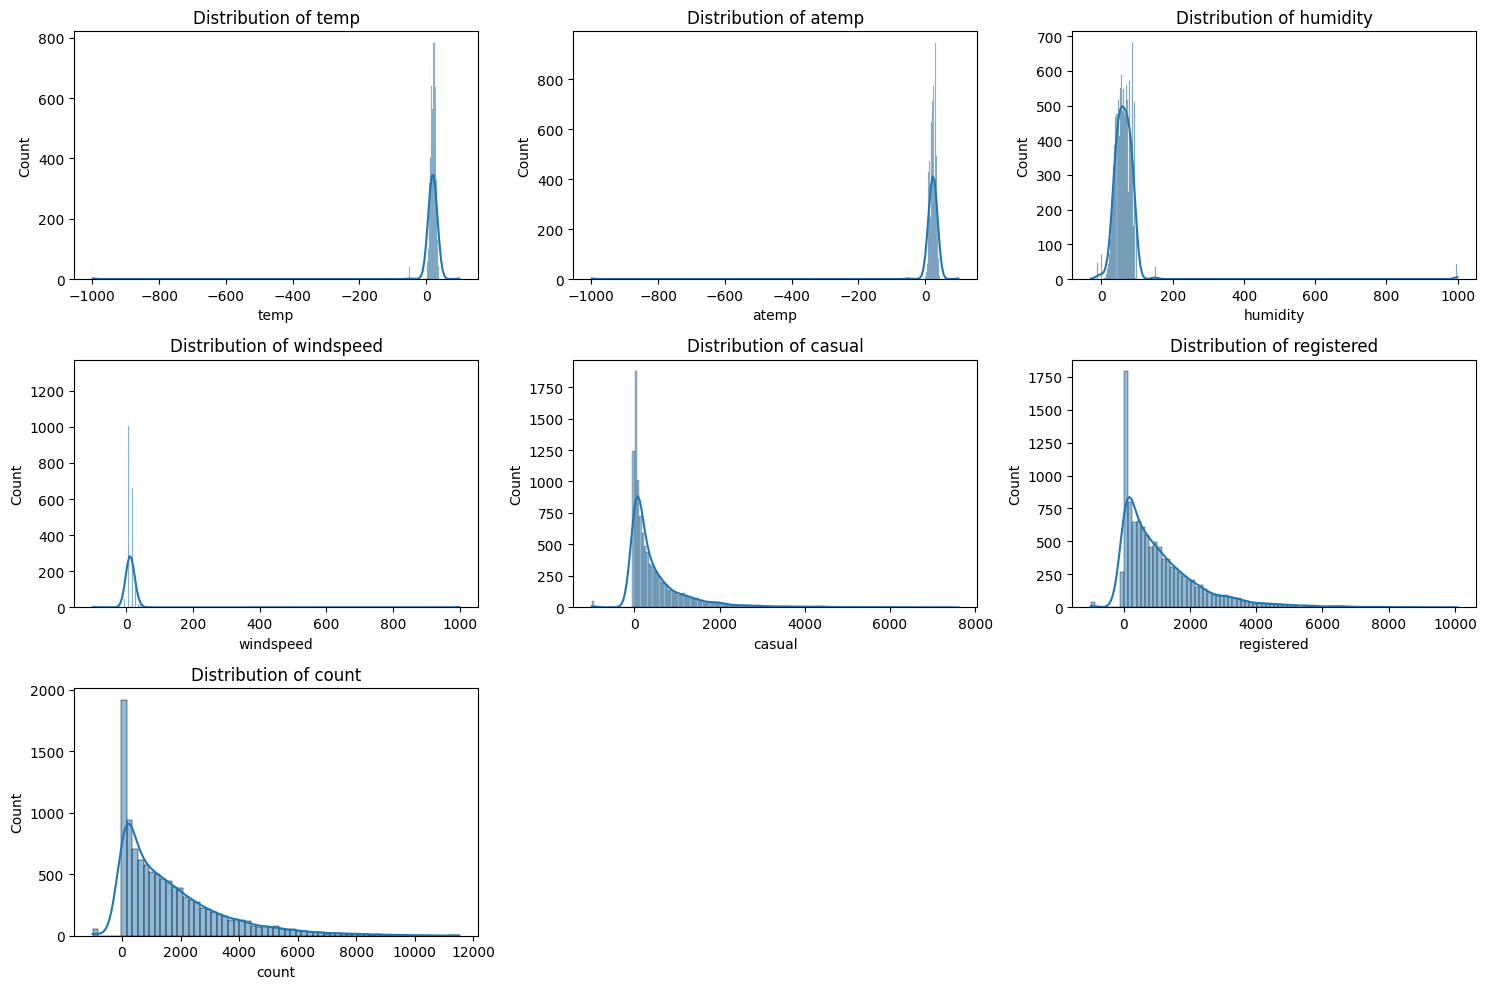

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate skewness for numerical columns
skewness = df_numeric.skew()
print("--- Skewness of Numerical Variables ---")
print(skewness)

# Visualize distributions to check for normality and outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df_numeric[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [ ]:

# 1.5 Outlier Detection using IQR Method

def detect_outliers_iqr(df, columns):
    outlier_indices = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outlier_indices[col] = {
            'count': len(outliers),
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'sample_outliers': outliers.unique()[:10] # Show first 10 unique outliers
        }

    return outlier_indices

# Perform detection on numerical columns
outlier_report = detect_outliers_iqr(df_numeric, num_cols)

print("--- IQR Outlier Detection Report ---")
for col, data in outlier_report.items():
    print(f"\nColumn: {col}")
    print(f"  Bounds: [{data['lower_bound']:.2f}, {data['upper_bound']:.2f}]")
    print(f"  Number of Outliers detected: {data['count']}")
    if data['count'] > 0:
        print(f"  Unique samples: {data['sample_outliers']}")

--- IQR Outlier Detection Report ---

Column: temp
  Bounds: [-4.51, 44.69]
  Number of Outliers detected: 122
  Unique samples: [ -50. -999.  100.]

Column: atemp
  Bounds: [-4.93, 52.65]
  Number of Outliers detected: 125
  Unique samples: [-999.  100.  -50. -100.]

Column: humidity
  Bounds: [-2.00, 126.00]
  Number of Outliers detected: 125
  Unique samples: [-10. 150. 999. -30.]

Column: windspeed
  Bounds: [-7.99, 31.99]
  Number of Outliers detected: 318
  Unique samples: [  32.9975   36.9974   35.0008   39.0007 -100.      999.       43.9989
   40.9973   51.9987   46.0022]

Column: casual
  Bounds: [-883.50, 1592.50]
  Number of Outliers detected: 942
  Unique samples: [-999. 1884. 2250. 1926. 1916. 2709. 3058. 1666. 4015. 2940.]

Column: registered
  Bounds: [-1874.50, 3713.50]
  Number of Outliers detected: 496
  Unique samples: [4132. 5185. 4671. 4902. 4756. 4523. 3809. 4682. 3830. 4557.]

Column: count
  Bounds: [-2916.50, 5663.50]
  Number of Outliers detected: 442
  Unique

1.6 Data Visualizations

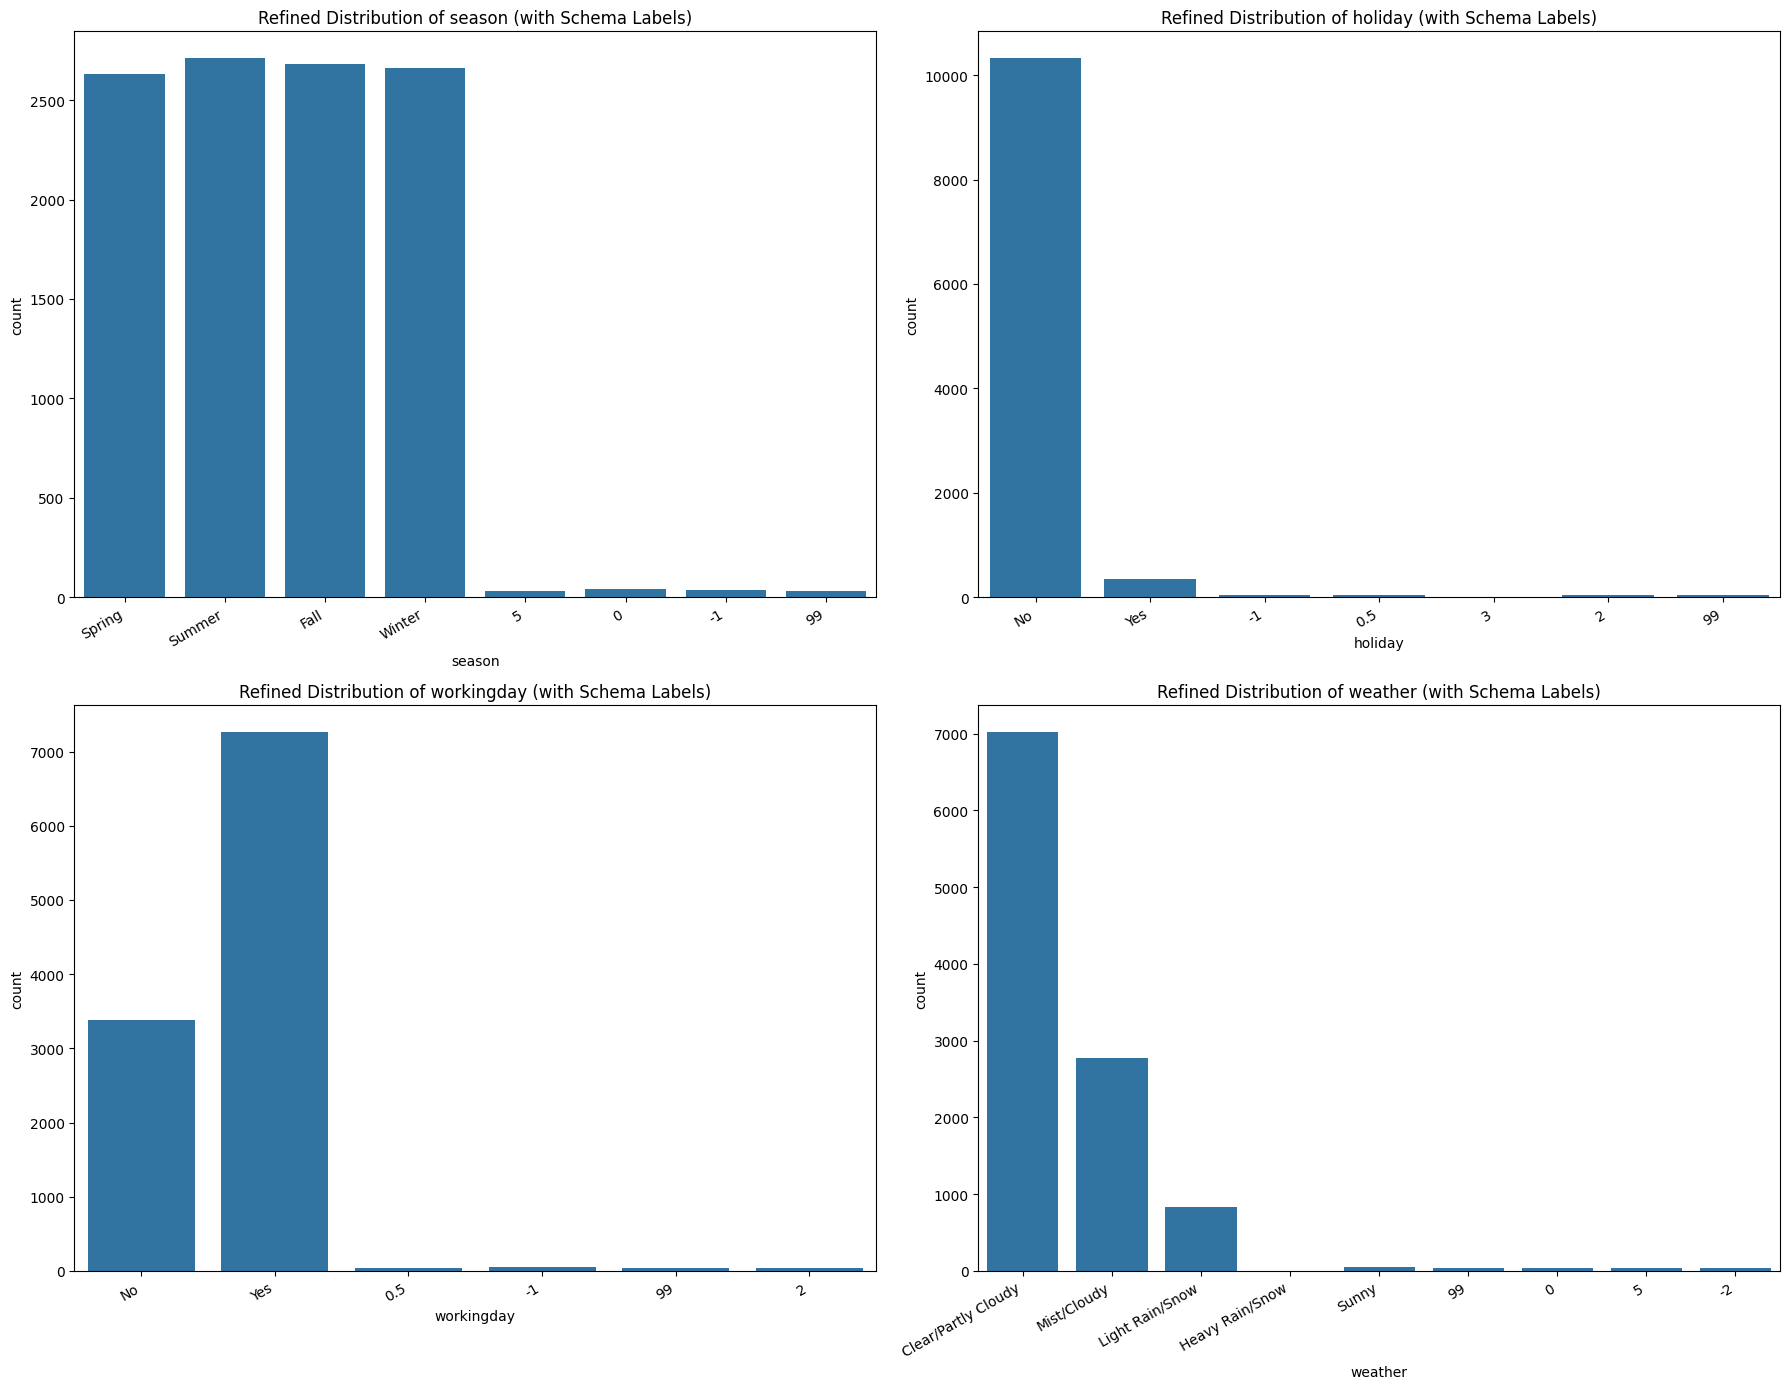

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1.6 Refined Categorical Visualizations with Mappings

# Define the mappings based on your provided schema
mappings = {
    'season': {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'},
    'holiday': {0: 'No', 1: 'Yes'},
    'workingday': {0: 'No', 1: 'Yes'},
    'weather': {
        1: 'Clear/Partly Cloudy',
        2: 'Mist/Cloudy',
        3: 'Light Rain/Snow',
        4: 'Heavy Rain/Snow'
    }
}

# Define cat_cols from the keys of the mappings dictionary
cat_cols = list(mappings.keys())

plt.figure(figsize=(18, 14))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)

    # Map the valid numeric codes to names, leave others as-is (anomalies)
    temp_series = df_rental[col].map(lambda x: mappings[col].get(x, x))

    # Order the bars for consistency
    order = list(mappings[col].values()) + [v for v in temp_series.unique() if v not in mappings[col].values() and pd.notna(v)]

    sns.countplot(x=temp_series, order=order)
    plt.title(f'Refined Distribution of {col} (with Schema Labels)')
    plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

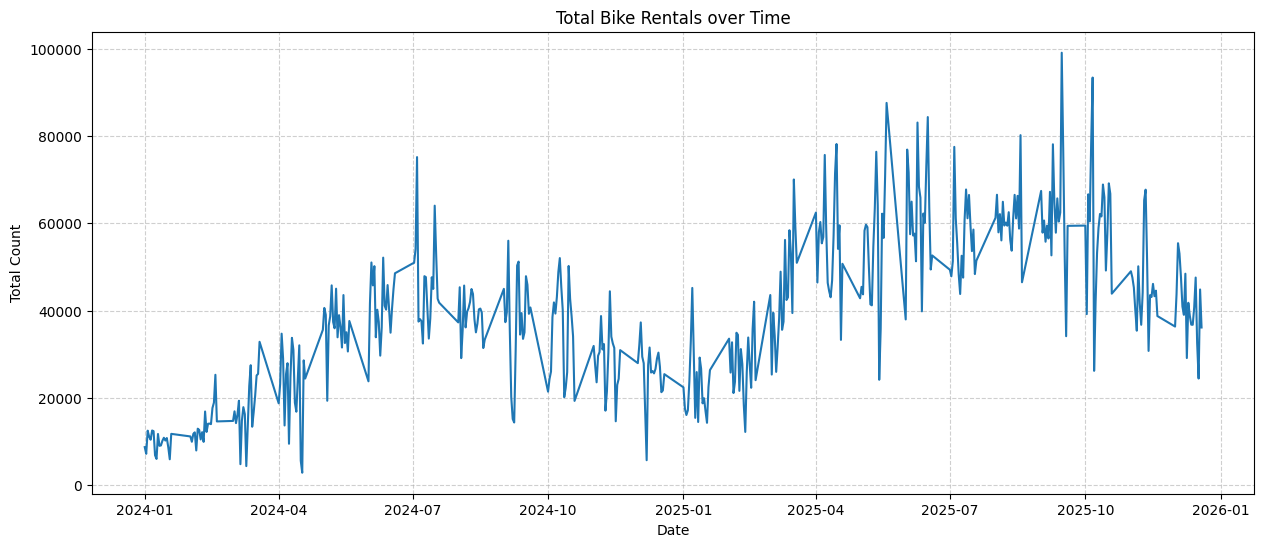

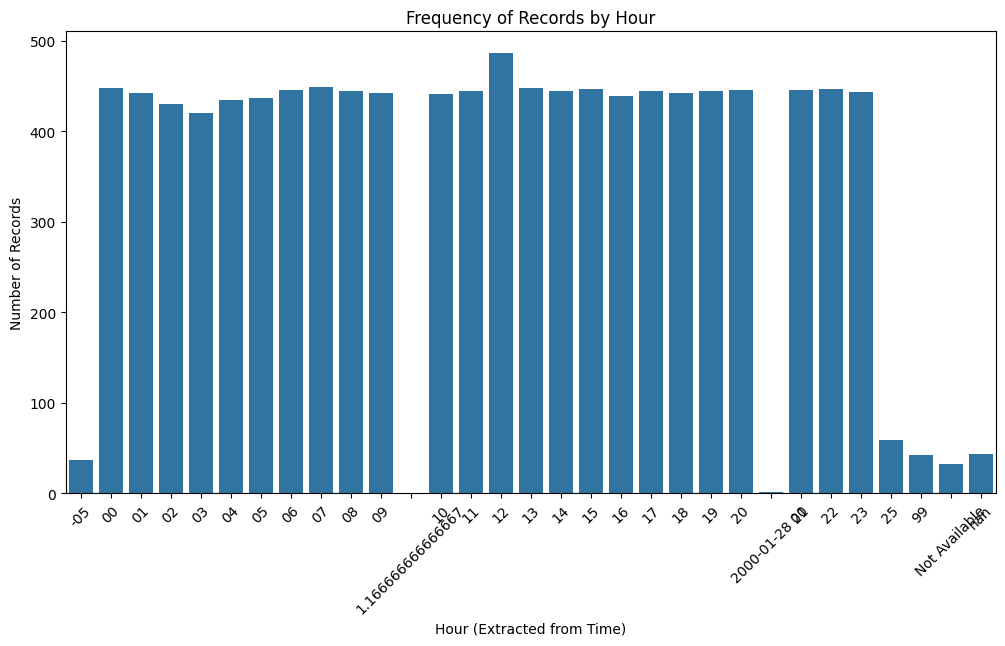

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Ensure date is in datetime format for plotting
df_rental['date'] = pd.to_datetime(df_rental['date'], errors='coerce')

# Plot 1: Total Count over Time (Chronological Order)
plt.figure(figsize=(15, 6))
df_daily = df_rental.groupby('date')['count'].sum().reset_index()
sns.lineplot(data=df_daily, x='date', y='count')
plt.title('Total Bike Rentals over Time')
plt.xlabel('Date')
plt.ylabel('Total Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot 2: Distribution of Records by Hour
plt.figure(figsize=(12, 6))
# Extracting hours from the 'time' column for visualization
# We convert to string first to handle mixed types safely
hours_series = df_rental['time'].astype(str).str.split(':').str[0]

# Sorting index to ensure hours 00-23 (and anomalies) are in order
sns.countplot(x=hours_series, order=sorted(hours_series.unique()))
plt.title('Frequency of Records by Hour')
plt.xlabel('Hour (Extracted from Time)')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

Data Cleaning

2.1 Handling Missing Values

MISSING VALUE REPORT
Total missing values: 773
Columns affected: 13

            Missing Count  Missing (%)
time                   44         0.40
date                   21         0.19
season                 51         0.47
holiday                37         0.34
workingday             54         0.50
weather                48         0.44
temp                   47         0.43
atemp                  45         0.41
humidity               39         0.36
windspeed              47         0.43
casual                115         1.06
registered            121         1.11
count                 104         0.96


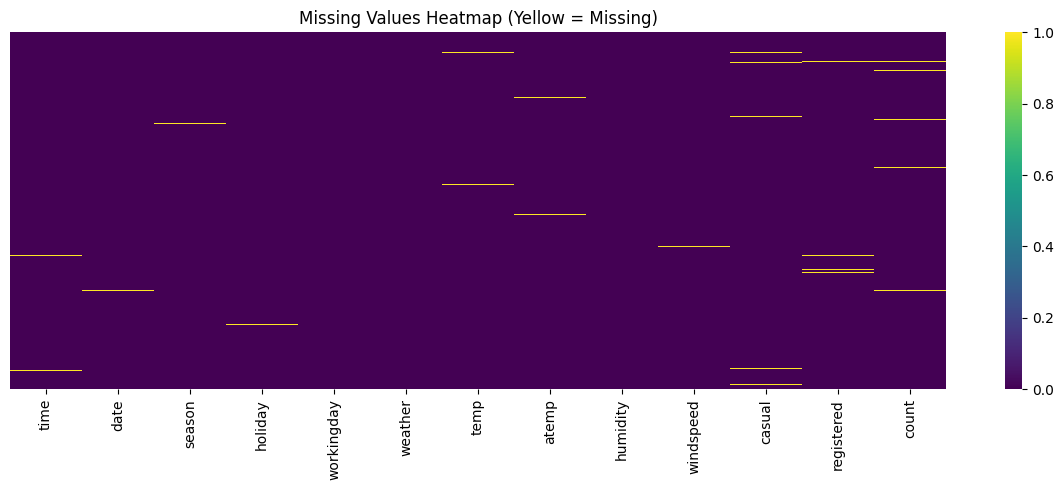

[Imputed] 'season' — filled 51 missing value(s) with mode: 3
[Imputed] 'holiday' — filled 37 missing value(s) with mode: 0
[Imputed] 'workingday' — filled 54 missing value(s) with mode: 1
[Imputed] 'weather' — filled 48 missing value(s) with mode: 1
[Imputed] 'temp' — filled 47 missing value(s) with median: 20.5000
[Imputed] 'atemp' — filled 45 missing value(s) with median: 24.2400
[Imputed] 'humidity' — filled 39 missing value(s) with median: 62.0000
[Imputed] 'windspeed' — filled 47 missing value(s) with median: 12.9980
[Imputed] 'casual' — filled 115 missing value(s) with median: 218.00
[Imputed] 'registered' — filled 121 missing value(s) with median: 768.00
[Imputed] 'count' — filled 104 missing value(s) with median: 1140.00
[Deleted] 65 row(s) with missing 'date' or 'time' values.

POST-CLEANING VERIFICATION
✓ No missing values remain. Dataset is clean.

Rows before cleaning : 10872
Rows after cleaning  : 10807
Rows removed         : 65


/tmp/ipykernel_1556/8124424.py:60: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(mode_val, inplace=True)
/tmp/ipykernel_1556/8124424.py:73: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

In [ ]:

# ============================================================
# 2.1 HANDLING MISSING VALUES
# ============================================================

import pandas as pd
import numpy as np

# -----------------------------------------------------------
# STEP 1: Detect missing values — Were there any? How many? Where?
# -----------------------------------------------------------

print("=" * 55)
print("MISSING VALUE REPORT")
print("=" * 55)

# Total missing per column
missing_counts = df_rental.isnull().sum()
missing_percent = (df_rental.isnull().sum() / len(df_rental)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing (%)': missing_percent.round(2)
})

# Filter only columns that actually have missing values
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

if missing_summary.empty:
    print("No missing values found in the dataset.")
else:
    print(f"Total missing values: {df_rental.isnull().sum().sum()}")
    print(f"Columns affected: {len(missing_summary)}\n")
    print(missing_summary)

# Visual heatmap of missing values
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))
sns.heatmap(df_rental.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------
# STEP 2: Apply method — Imputation or Deletion
# -----------------------------------------------------------

df_cleaned = df_rental.copy()

# -- Categorical columns: impute with MODE --
# Justification: Season, holiday, workingday, weather are discrete categories.
# Dropping rows would lose valid data in other columns.
# Mode preserves the most common pattern, which is appropriate for categories.
categorical_cols = ['season', 'holiday', 'workingday', 'weather']

for col in categorical_cols:
    if df_cleaned[col].isnull().sum() > 0:
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val, inplace=True)
        print(f"[Imputed] '{col}' — filled {df_rental[col].isnull().sum()} missing value(s) with mode: {mode_val}")

# -- Continuous numeric columns: impute with MEDIAN --
# Justification: Temp, atemp, humidity, windspeed can be skewed.
# Median is more robust to outliers than mean, preventing imputation from
# distorting the distribution identified in section 1.3/1.5.
continuous_cols = ['temp', 'atemp', 'humidity', 'windspeed']

for col in continuous_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
    if df_cleaned[col].isnull().sum() > 0:
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"[Imputed] '{col}' — filled {df_rental[col].isnull().sum()} missing value(s) with median: {median_val:.4f}")

# -- Count columns: impute with MEDIAN --
# Justification: Rental counts (casual, registered, count) are right-skewed
# (as seen in skewness analysis). Median is preferred over mean for skewed data.
count_cols = ['casual', 'registered', 'count']

for col in count_cols:
    if df_cleaned[col].isnull().sum() > 0:
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val, inplace=True)
        print(f"[Imputed] '{col}' — filled {df_rental[col].isnull().sum()} missing value(s) with median: {median_val:.2f}")

# -- Date/Time columns: DELETE rows if missing --
# Justification: Date and time are index-like identifiers — imputing them
# would create fabricated timestamps with no real meaning.
# The dataset is large enough that row deletion has negligible impact.
rows_before = len(df_cleaned)

df_cleaned = df_cleaned.dropna(subset=['date', 'time'])

rows_dropped = rows_before - len(df_cleaned)
if rows_dropped > 0:
    print(f"[Deleted] {rows_dropped} row(s) with missing 'date' or 'time' values.")

# -----------------------------------------------------------
# STEP 3: Verify — confirm no missing values remain
# -----------------------------------------------------------

print("\n" + "=" * 55)
print("POST-CLEANING VERIFICATION")
print("=" * 55)

remaining = df_cleaned.isnull().sum()
if remaining.sum() == 0:
    print("✓ No missing values remain. Dataset is clean.")
else:
    print("⚠ Remaining missing values:")
    print(remaining[remaining > 0])

print(f"\nRows before cleaning : {len(df_rental)}")
print(f"Rows after cleaning  : {len(df_cleaned)}")
print(f"Rows removed         : {len(df_rental) - len(df_cleaned)}")

Managing Outliers (2.2)


OUTLIER TREATMENT REPORT
    Column             Method  Lower Bound  Upper Bound  Outliers Treated                  Intentionally Kept
      temp       Capped (IQR)      -4.5100      44.6900               120                                  No
     atemp       Capped (IQR)      -4.9275      52.6525               123                                  No
  humidity       Capped (IQR)       0.5000     124.5000               189                                  No
 windspeed       Capped (IQR)      -7.9931      31.9925               314                                  No
    casual Kept (Intentional)    -863.7500    1562.2500               960 Yes — demand spikes are real signal
registered Kept (Intentional)   -1840.5000    3671.5000               511 Yes — demand spikes are real signal
     count Kept (Intentional)   -2867.7500    5598.2500               460 Yes — demand spikes are real signal


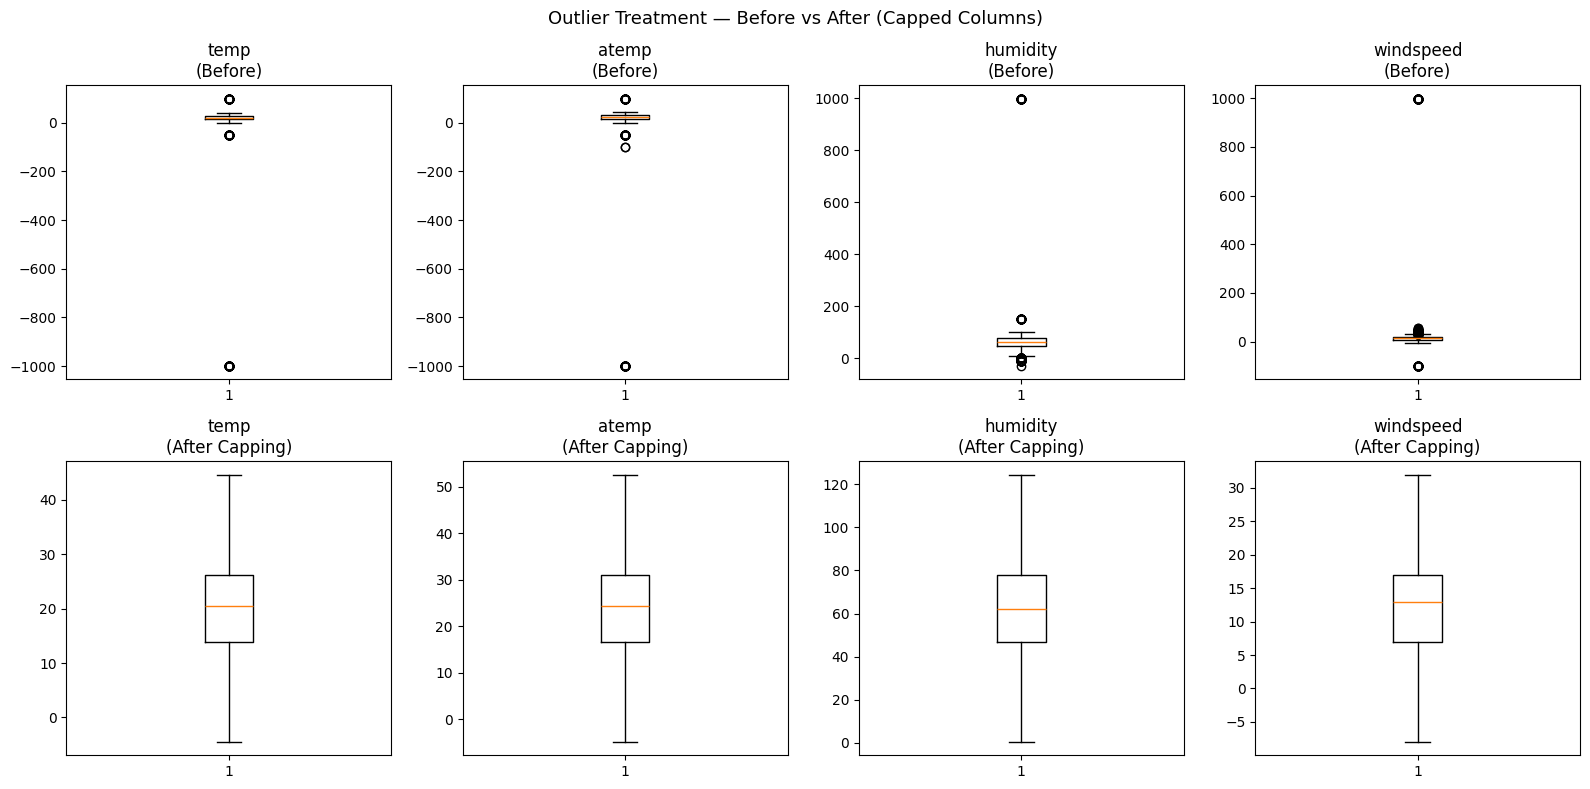

In [ ]:
# ============================================================
# 2.2 HANDLING OUTLIERS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
df_numeric = df_cleaned[num_cols].apply(pd.to_numeric, errors='coerce')

# -----------------------------------------------------------
# STEP 1: IQR-based capping (Winsorization)
# -----------------------------------------------------------
# Method: IQR chosen over Z-Score because our skewness analysis
# showed non-normal distributions. Z-Score assumes normality —
# IQR makes no such assumption and is robust to skewed data.

df_outlier_treated = df_cleaned.copy()
outlier_summary = []

# Columns where outliers are CAPPED (Winsorized)
# Justification: temp, atemp, humidity, windspeed are real-world
# weather readings — extreme values are genuinely possible and
# carry signal. Capping preserves the row while limiting distortion.
cap_cols = ['temp', 'atemp', 'humidity', 'windspeed']

for col in cap_cols:
    series = pd.to_numeric(df_outlier_treated[col], errors='coerce')
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((series < lower) | (series > upper)).sum()
    df_outlier_treated[col] = series.clip(lower=lower, upper=upper)

    outlier_summary.append({
        'Column': col,
        'Method': 'Capped (IQR)',
        'Lower Bound': round(lower, 4),
        'Upper Bound': round(upper, 4),
        'Outliers Treated': n_outliers,
        'Intentionally Kept': 'No'
    })

# Columns where outliers are KEPT INTENTIONALLY
# Justification: casual, registered, count represent real rental
# demand spikes (events, holidays, peak seasons). These are not
# errors — they are the most analytically interesting data points.
# Removing or capping them would hide genuine demand patterns.
keep_cols = ['casual', 'registered', 'count']

for col in keep_cols:
    series = pd.to_numeric(df_outlier_treated[col], errors='coerce')
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((series < lower) | (series > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Method': 'Kept (Intentional)',
        'Lower Bound': round(lower, 4),
        'Upper Bound': round(upper, 4),
        'Outliers Treated': n_outliers,
        'Intentionally Kept': 'Yes — demand spikes are real signal'
    })

# -----------------------------------------------------------
# STEP 2: Print summary report
# -----------------------------------------------------------

print("=" * 60)
print("OUTLIER TREATMENT REPORT")
print("=" * 60)
summary_df = pd.DataFrame(outlier_summary)
print(summary_df.to_string(index=False))

# -----------------------------------------------------------
# STEP 3: Before vs After boxplots for capped columns
# -----------------------------------------------------------

fig, axes = plt.subplots(2, len(cap_cols), figsize=(16, 8))

for i, col in enumerate(cap_cols):
    original = pd.to_numeric(df_cleaned[col], errors='coerce')
    treated = pd.to_numeric(df_outlier_treated[col], errors='coerce')

    axes[0, i].boxplot(original.dropna())
    axes[0, i].set_title(f'{col}\n(Before)')

    axes[1, i].boxplot(treated.dropna())
    axes[1, i].set_title(f'{col}\n(After Capping)')

plt.suptitle('Outlier Treatment — Before vs After (Capped Columns)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
df_outlier_treated.to_excel('Cleaned_Database_Project.xlsx', index=False)

In [ ]:
#show all possible values in df_outliers_treated
for col in df_outlier_treated.columns:
    unique_values = df_outlier_treated[col].unique()
    print(f"Unique values in column '{col}':")
    print(unique_values)
    print()

Unique values in column 'time':
['00:00:00' '01:00:00' '02:00:00' '03:00:00' '04:00:00' '05:00:00'
 '06:00:00' '07:00:00' '08:00:00' '09:00:00' '10:00:00' '11:00:00'
 '12:00:00' '13:00:00' '14:00:00' '15:00:00' '16:00:00' '17:00:00'
 '18:00:00' '25:00' '20:00:00' '21:00:00' '22:00:00' '23:00:00' '12:99'
 '19:00:00' '-05:00' 'Not Available' '99:99' 1.166666666666667
 datetime.datetime(2000, 1, 28, 0, 0)]

Unique values in column 'date':
<DatetimeArray>
['2024-01-01 00:00:00', '2024-01-02 00:00:00', '2024-01-03 00:00:00',
 '2024-01-04 00:00:00', '2024-01-05 00:00:00', '2024-01-06 00:00:00',
 '2024-01-07 00:00:00', '2024-01-08 00:00:00', '2024-01-09 00:00:00',
 '2024-01-10 00:00:00',
 ...
 '2025-12-10 00:00:00', '2025-12-11 00:00:00', '2025-12-12 00:00:00',
 '2025-12-13 00:00:00', '2025-12-14 00:00:00', '2025-12-15 00:00:00',
 '2025-12-16 00:00:00', '2025-12-17 00:00:00', '2025-12-18 00:00:00',
 '2025-12-19 00:00:00']
Length: 456, dtype: datetime64[ns]

Unique values in column 'season':
[

In [ ]:
df_cleaned_anomalies = df_outlier_treated.copy()

print("--- Cleaning Anomalous Categorical Values ---")

# Define valid values and mappings for string anomalies
# Mode values are based on the imputation done in the previous cleaning step
column_configs = {
    'season': {
        'valid_values': [1, 2, 3, 4],
        'str_map': {'Summer': 2},
        'mode_val': 3
    },
    'holiday': {
        'valid_values': [0, 1],
        'str_map': {'Yes': 1},
        'mode_val': 0
    },
    'workingday': {
        'valid_values': [0, 1],
        'str_map': {'Yes': 1, 'No': 0},
        'mode_val': 1
    },
    'weather': {
        'valid_values': [1, 2, 3, 4],
        'str_map': {'Sunny': 1}, # 'Sunny' implies clear weather (weather code 1)
        'mode_val': 1
    }
}

for col, config in column_configs.items():
    print(f"\nProcessing column: '{col}'")
    original_unique = df_cleaned_anomalies[col].unique()
    print(f"  Original unique values: {original_unique}")

    # Step 1: Standardize string representations
    if config['str_map']:
        df_cleaned_anomalies[col] = df_cleaned_anomalies[col].replace(config['str_map'])
        print(f"  Applied string mappings: {config['str_map']}")

    # Step 2: Convert to numeric, coercing errors to NaN
    # This handles any remaining non-numeric strings or types that couldn't be mapped
    df_cleaned_anomalies[col] = pd.to_numeric(df_cleaned_anomalies[col], errors='coerce')

    # Step 3: Identify and replace out-of-schema numeric values with NaN
    # Filter for values that are not NaN and not in the valid_values list
    invalid_numeric_mask = df_cleaned_anomalies[col].notna() & ~df_cleaned_anomalies[col].isin(config['valid_values'])
    if invalid_numeric_mask.any():
        num_anomalies_before_imputation = df_cleaned_anomalies.loc[invalid_numeric_mask, col].nunique()
        df_cleaned_anomalies.loc[invalid_numeric_mask, col] = np.nan
        print(f"  Replaced {num_anomalies_before_imputation} out-of-schema numeric anomalies with NaN.")

    # Step 4: Impute remaining NaNs with the determined mode
    # Using the mode from the previous general cleaning step ensures consistency.
    initial_nan_count = df_cleaned_anomalies[col].isnull().sum()
    if initial_nan_count > 0:
        df_cleaned_anomalies[col].fillna(config['mode_val'], inplace=True)
        print(f"  Imputed {initial_nan_count} NaN values with mode: {config['mode_val']}")

    # Final conversion to integer type to ensure consistency
    df_cleaned_anomalies[col] = df_cleaned_anomalies[col].astype(int)
    print(f"  Final unique values for '{col}': {df_cleaned_anomalies[col].unique()}")

# Verify all values are now valid
print("\n--- Verification of Categorical Columns ---")
for col, config in column_configs.items():
    invalid_values = [v for v in df_cleaned_anomalies[col].unique() if v not in config['valid_values']]
    if not invalid_values:
        print(f"✓ Column '{col}': All values are within valid schema: {config['valid_values']}")
    else:
        print(f"X Column '{col}': Found invalid values: {invalid_values} (Expected: {config['valid_values']})")

# Update df_outlier_treated with the cleaned DataFrame
df_outlier_treated = df_cleaned_anomalies.copy()

# Display unique values after cleaning to confirm
print("\n--- Unique values in df_outlier_treated after fixing anomalies ---")
for col in column_configs.keys():
    print(f"'{col}': {df_outlier_treated[col].unique()}")

--- Cleaning Anomalous Categorical Values ---

Processing column: 'season'
  Original unique values: [1 3 5 'Summer' 0 -1 99 2 4]
  Applied string mappings: {'Summer': 2}
  Replaced 4 out-of-schema numeric anomalies with NaN.
  Imputed 135 NaN values with mode: 3
  Final unique values for 'season': [1 3 2 4]

Processing column: 'holiday'
  Original unique values: [0 -1 0.5 3 2 1 'Yes' 99]
  Applied string mappings: {'Yes': 1}
  Replaced 5 out-of-schema numeric anomalies with NaN.
  Imputed 160 NaN values with mode: 0
  Final unique values for 'holiday': [0 1]

Processing column: 'workingday'
  Original unique values: [0 0.5 -1 1 'Yes' 99 2 'No']
  Applied string mappings: {'Yes': 1, 'No': 0}
  Replaced 4 out-of-schema numeric anomalies with NaN.
  Imputed 176 NaN values with mode: 1
  Final unique values for 'workingday': [0 1]

Processing column: 'weather'
  Original unique values: [1 2 'Sunny' 3 99 0 5 -2 4]
  Applied string mappings: {'Sunny': 1}
  Replaced 4 out-of-schema numeric a

/tmp/ipykernel_1556/547212818.py:37: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cleaned_anomalies[col] = df_cleaned_anomalies[col].replace(config['str_map'])
/tmp/ipykernel_1556/547212818.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned_anomalies[col].fillna(config['mode_val'], 

In [ ]:
#show all possible values in df_outliers_treated
for col in df_outlier_treated.columns:
    unique_values = df_outlier_treated[col].unique()
    print(f"Unique values in column '{col}':")
    print(unique_values)
    print()

Unique values in column 'time':
['00:00:00' '01:00:00' '02:00:00' '03:00:00' '04:00:00' '05:00:00'
 '06:00:00' '07:00:00' '08:00:00' '09:00:00' '10:00:00' '11:00:00'
 '12:00:00' '13:00:00' '14:00:00' '15:00:00' '16:00:00' '17:00:00'
 '18:00:00' '25:00' '20:00:00' '21:00:00' '22:00:00' '23:00:00' '12:99'
 '19:00:00' '-05:00' 'Not Available' '99:99' 1.166666666666667
 datetime.datetime(2000, 1, 28, 0, 0)]

Unique values in column 'date':
<DatetimeArray>
['2024-01-01 00:00:00', '2024-01-02 00:00:00', '2024-01-03 00:00:00',
 '2024-01-04 00:00:00', '2024-01-05 00:00:00', '2024-01-06 00:00:00',
 '2024-01-07 00:00:00', '2024-01-08 00:00:00', '2024-01-09 00:00:00',
 '2024-01-10 00:00:00',
 ...
 '2025-12-10 00:00:00', '2025-12-11 00:00:00', '2025-12-12 00:00:00',
 '2025-12-13 00:00:00', '2025-12-14 00:00:00', '2025-12-15 00:00:00',
 '2025-12-16 00:00:00', '2025-12-17 00:00:00', '2025-12-18 00:00:00',
 '2025-12-19 00:00:00']
Length: 456, dtype: datetime64[ns]

Unique values in column 'season':
[

Updated Summary Statistics (2.3)


In [ ]:
# Updated Statistics After Cleaning
df_outlier_treated.describe()

,date,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10807,10807.000000,10807.000000,10807.000000,10807.00000,10807.000000,10807.000000,10807.000000,10807.000000,10807.000000,10807.000000,10807.000000
mean,2024-12-26 11:12:45.836957696,2.511613,0.031924,0.690016,1.41066,20.061888,23.447356,61.859952,12.603168,521.040529,1139.982789,1668.142778
min,2024-01-01 00:00:00,1.000000,0.000000,0.000000,1.00000,-4.510000,-4.927500,0.500000,-7.993100,-999.000000,-999.000000,-999.000000
25%,2024-07-02 00:00:00,2.000000,0.000000,0.000000,1.00000,13.940000,16.665000,47.000000,7.001500,46.000000,226.500000,307.000000
50%,2025-01-02 00:00:00,3.000000,0.000000,1.000000,1.00000,20.500000,24.240000,62.000000,12.998000,218.000000,768.000000,1140.000000
75%,2025-07-01 00:00:00,3.000000,0.000000,1.000000,2.00000,26.240000,31.060000,78.000000,16.997900,652.500000,1604.500000,2423.500000
max,2025-12-19 00:00:00,4.000000,1.000000,1.000000,4.00000,44.690000,52.652500,124.500000,31.992500,7606.000000,10076.000000,11530.000000
std,NaN,1.107338,0.175805,0.462508,0.63019,8.211121,9.038132,20.505926,8.114815,813.486668,1255.718242,1770.894685


### 2.4 Updated Visualizations (After Cleaning)

--- Skewness Before Cleaning ---
temp         -14.419801
atemp        -15.603784
humidity      13.214800
windspeed     13.751731
casual         2.985121
registered     1.982499
count          1.603851
dtype: float64

--- Skewness After Cleaning ---
temp         -0.117317
atemp        -0.221123
humidity     -0.083012
windspeed     0.297234
casual        3.095473
registered    2.031010
count         1.642093
dtype: float64

--- Distribution Comparison (Before vs. After Cleaning) ---


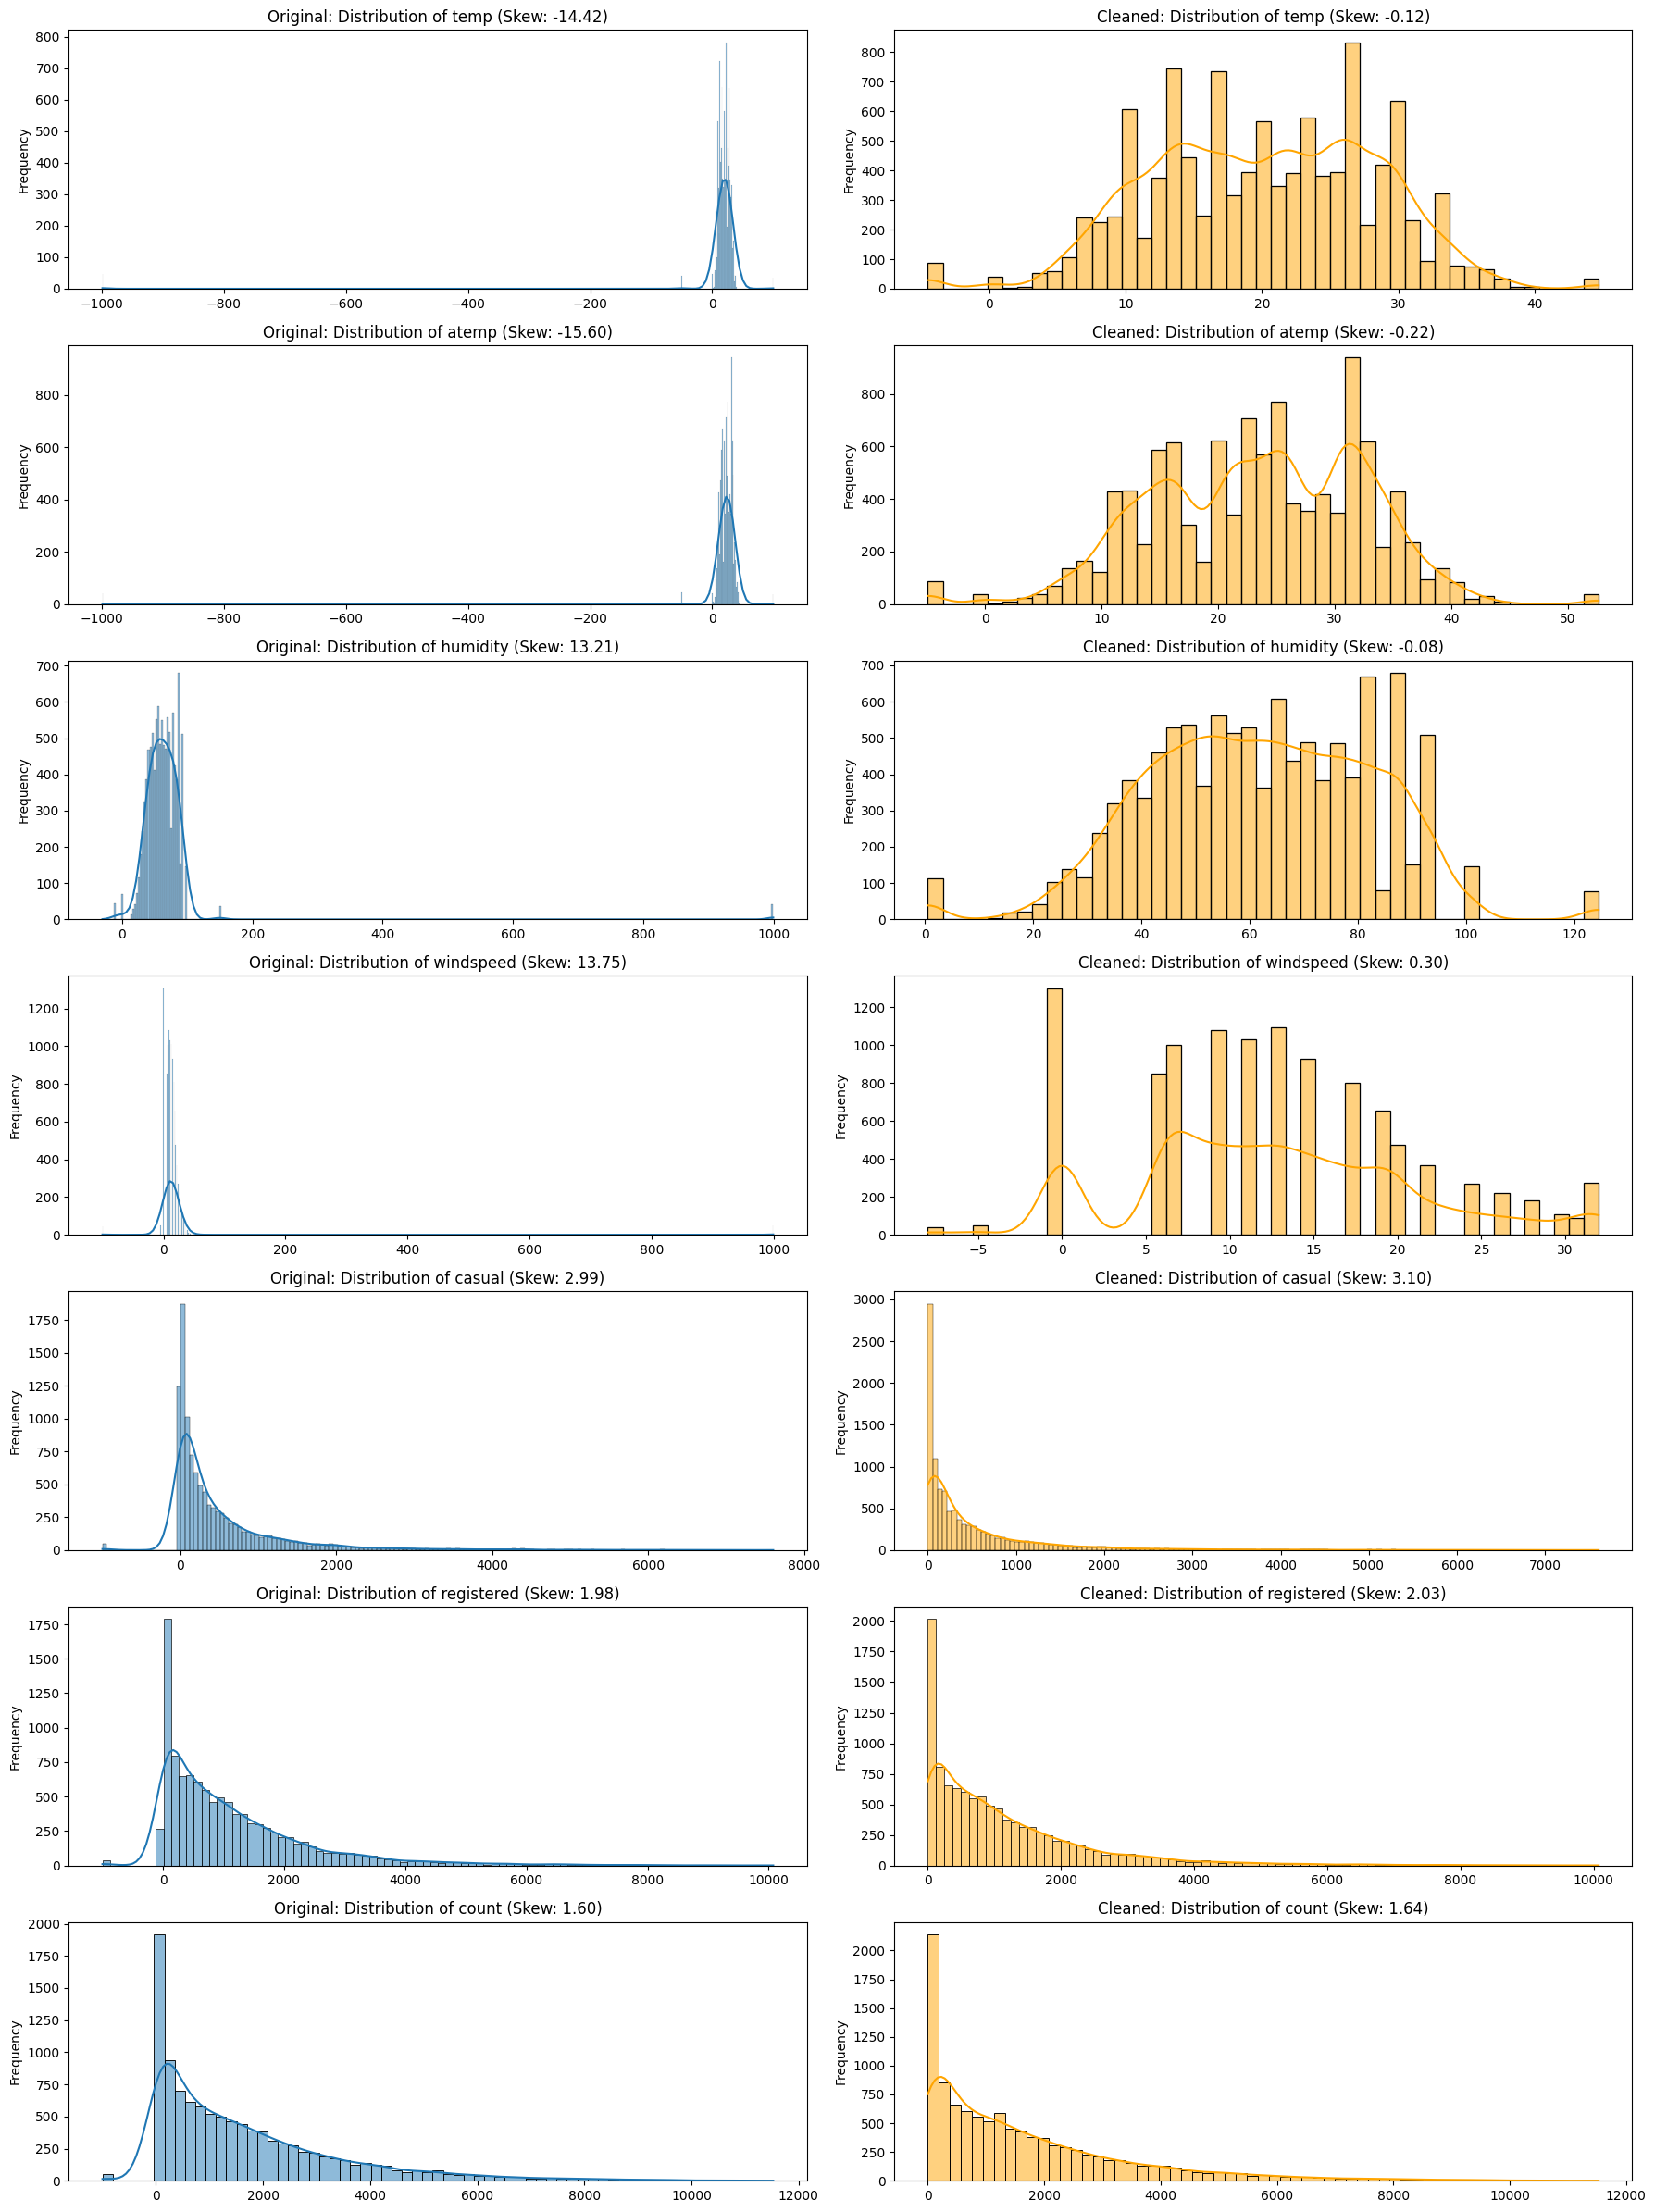

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define numerical columns
num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']

# Prepare dataframes for numerical analysis, coercing errors to NaN
df_original_numeric = df_rental[num_cols].apply(pd.to_numeric, errors='coerce')
df_cleaned_numeric = df_outlier_treated[num_cols].apply(pd.to_numeric, errors='coerce')

# --- 1. Skewness Comparison ---
print("--- Skewness Before Cleaning ---")
print(df_original_numeric.skew())
print("\n--- Skewness After Cleaning ---")
print(df_cleaned_numeric.skew())

# --- 2. Distribution Comparison (Before vs. After) ---
print("\n--- Distribution Comparison (Before vs. After Cleaning) ---")

plt.figure(figsize=(18, 24))

for i, col in enumerate(num_cols):
    # Before Cleaning
    plt.subplot(len(num_cols), 2, 2 * i + 1)
    sns.histplot(df_original_numeric[col].dropna(), kde=True)
    plt.title(f'Original: Distribution of {col} (Skew: {df_original_numeric[col].skew():.2f})')
    plt.xlabel('')
    plt.ylabel('Frequency')

    # After Cleaning
    plt.subplot(len(num_cols), 2, 2 * i + 2)
    sns.histplot(df_cleaned_numeric[col].dropna(), kde=True, color='orange')
    plt.title(f'Cleaned: Distribution of {col} (Skew: {df_cleaned_numeric[col].skew():.2f})')
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

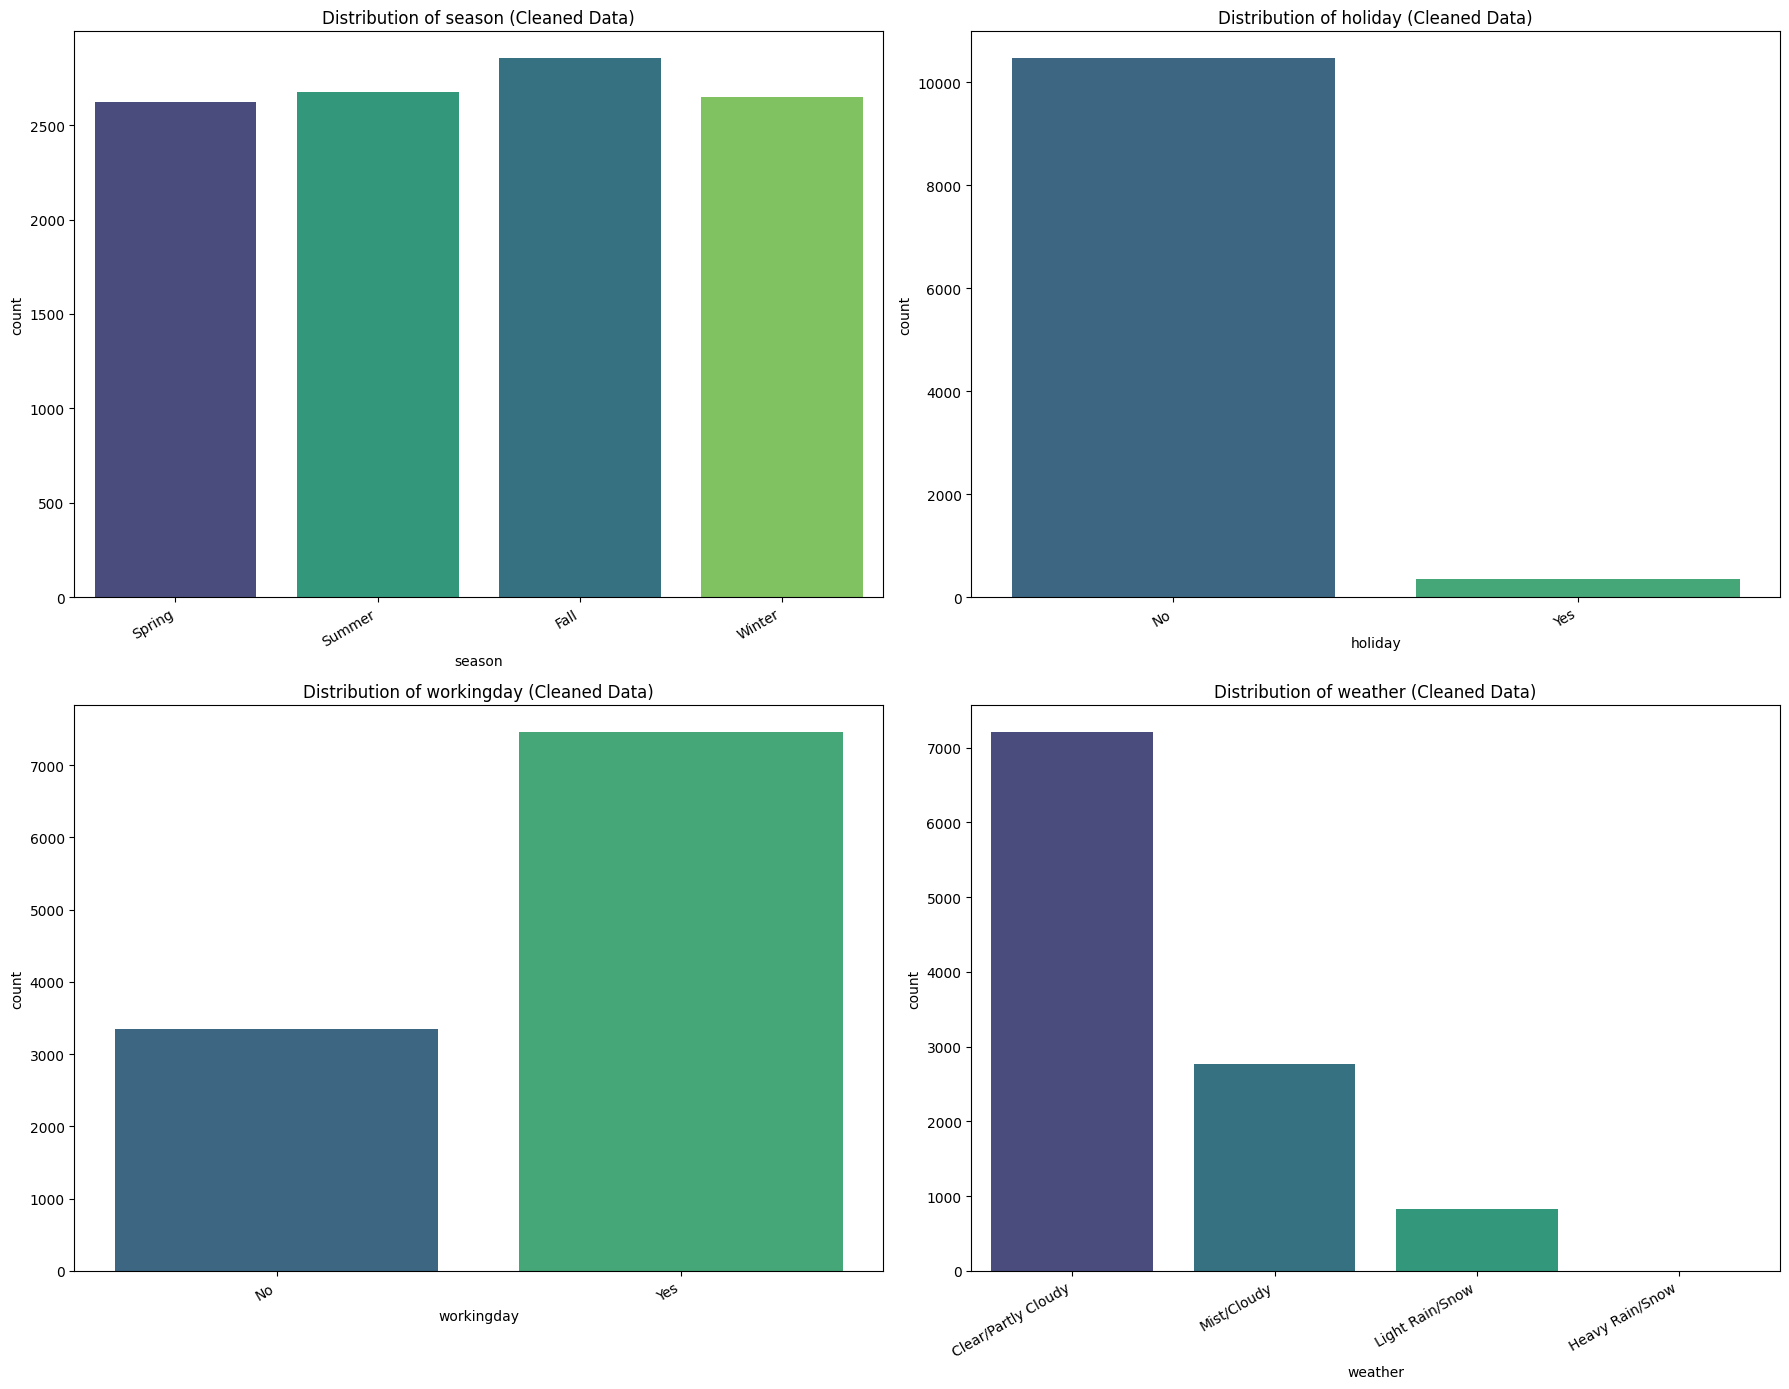

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1.6 Refined Categorical Visualizations with Mappings (using cleaned data)

# Define the mappings based on your provided schema
mappings = {
    'season': {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'},
    'holiday': {0: 'No', 1: 'Yes'},
    'workingday': {0: 'No', 1: 'Yes'},
    'weather': {
        1: 'Clear/Partly Cloudy',
        2: 'Mist/Cloudy',
        3: 'Light Rain/Snow',
        4: 'Heavy Rain/Snow'
    }
}

# Define cat_cols from the keys of the mappings dictionary
cat_cols = list(mappings.keys())

plt.figure(figsize=(18, 14))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)

    # Map the valid numeric codes to names
    temp_series = df_cleaned_viz[col].map(lambda x: mappings[col].get(x, x))

    # Order the bars for consistency
    order = list(mappings[col].values())

    sns.countplot(x=temp_series, hue=temp_series, order=order, palette='viridis', legend=False)
    plt.title(f'Distribution of {col} (Cleaned Data)')
    plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

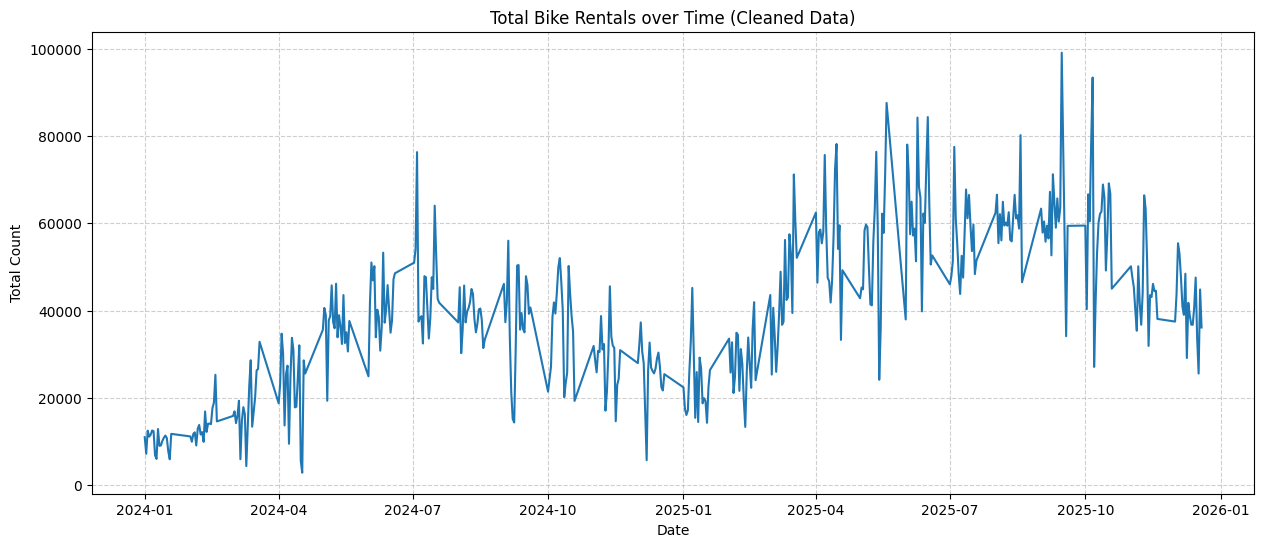

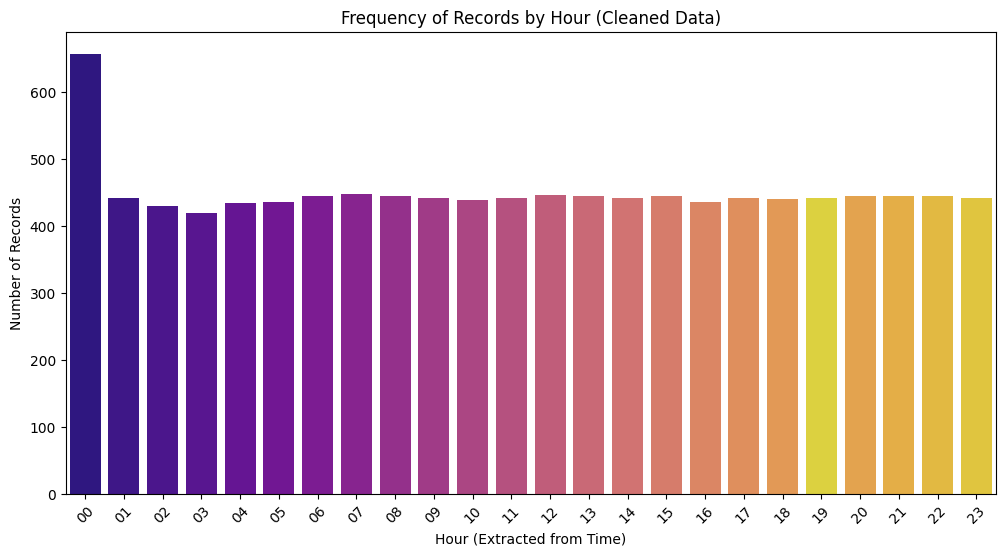

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure date is in datetime format for plotting
df_cleaned_viz['date'] = pd.to_datetime(df_cleaned_viz['date'], errors='coerce')

# Plot 1: Total Count over Time (Chronological Order)
plt.figure(figsize=(15, 6))
df_daily_cleaned = df_cleaned_viz.groupby('date')['count'].sum().reset_index()
sns.lineplot(data=df_daily_cleaned, x='date', y='count')
plt.title('Total Bike Rentals over Time (Cleaned Data)')
plt.xlabel('Date')
plt.ylabel('Total Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Plot 2: Distribution of Records by Hour
plt.figure(figsize=(12, 6))
# Extracting hours from the 'time' column for visualization
hours_series_cleaned = df_cleaned_viz['time'].astype(str).str.split(':').str[0]

# Sorting index to ensure hours 00-23 are in order
sns.countplot(x=hours_series_cleaned, hue=hours_series_cleaned, order=sorted(hours_series_cleaned.unique()), palette='plasma', legend=False)
plt.title('Frequency of Records by Hour (Cleaned Data)')
plt.xlabel('Hour (Extracted from Time)')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.show()

In [56]:
#Export clean dataset into Excel
df_cleaned_viz.to_excel('Cleaned_Database_Project_1.xlsx', index=False)